# Ejercicio Práctico — Análisis Estadístico de Simulación Bancaria
### Comparación de escenarios: 2, 4 y 6 cajeros

## 1. Importación de librerías

In [2]:
!pip install simpy

In [3]:
import simpy
import random
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import pandas as pd
import os

## 2. Parámetros globales del sistema

- **Llegadas:** distribución Uniforme(2, 5) minutos entre llegadas.
- **Servicio:** distribución Exponencial con media de 10 minutos.
- **Tiempo de simulación:** 600 minutos (10 horas).
- **Calentamiento (warm-up):** primeros 120 minutos, se descartan del análisis.
- **Replicaciones:** 100 por escenario.

In [4]:
TASA_LLEGADA_MIN = 2.0      # Tiempo min entre llegadas (dist. Uniforme)
TASA_LLEGADA_MAX = 5.0      # Tiempo max entre llegadas (dist. Uniforme)
MEDIA_SERVICIO = 10.0       # Tiempo promedio de servicio (dist. Exponencial)
TIEMPO_SIMULACION = 600     # 10 horas de simulación (minutos)
TIEMPO_CALENTAMIENTO = 120  # Ignorar los primeros 120 min (Warm-up)
NUM_REPLICACIONES = 100     # Replicaciones experimentales

CARPETA_GRAFICAS = "graficas"
os.makedirs(CARPETA_GRAFICAS, exist_ok=True)

## 3. Arquitectura del modelo (POO)

La clase `SucursalBancaria` representa el sistema, con los cajeros como
**recurso compartido** (`simpy.Resource`). El proceso `cliente_flow`
define el ciclo de vida de cada cliente (entidad): llegada → espera →
atención → salida.

In [5]:
class SucursalBancaria:
    def __init__(self, env, num_cajeros):
        self.env = env
        self.num_cajeros = num_cajeros
        self.cajeros = simpy.Resource(env, num_cajeros)

        # Estructuras para almacenar métricas de desempeño
        self.tiempos_espera_cola = []
        self.tiempos_totales_sistema = []
        self.tiempo_ocupado_cajeros = {i: 0.0 for i in range(num_cajeros)}

    def atender_cliente(self, cliente_id, cajero_id):
        """Simula el proceso estocástico de atención."""
        tiempo_servicio = random.expovariate(1.0 / MEDIA_SERVICIO)
        yield self.env.timeout(tiempo_servicio)

        if self.env.now > TIEMPO_CALENTAMIENTO:
            self.tiempo_ocupado_cajeros[cajero_id] += tiempo_servicio

In [6]:
def cliente_flow(env, nombre, sucursal):
    """Define el ciclo de vida de la entidad dentro del sistema."""
    llegada = env.now

    with sucursal.cajeros.request() as peticion:
        yield peticion
        espera = env.now - llegada

        cajero_asignado = len(sucursal.cajeros.users) - 1
        yield env.process(sucursal.atender_cliente(nombre, cajero_asignado))

        salida = env.now

        if salida > TIEMPO_CALENTAMIENTO:
            sucursal.tiempos_espera_cola.append(espera)
            sucursal.tiempos_totales_sistema.append(salida - llegada)

In [7]:
def generador_llegadas(env, sucursal):
    """Inyecta entidades al sistema usando una distribución Uniforme."""
    i = 0
    while True:
        yield env.timeout(random.uniform(TASA_LLEGADA_MIN, TASA_LLEGADA_MAX))
        i += 1
        env.process(cliente_flow(env, f'Cliente_{i}', sucursal))

## 4. Motor de ejecución y recolección de datos

In [8]:
def ejecutar_replica(semilla, num_cajeros):
    """Ejecuta una réplica aislada y retorna sus promedios."""
    random.seed(semilla)
    env = simpy.Environment()
    sucursal = SucursalBancaria(env, num_cajeros)

    env.process(generador_llegadas(env, sucursal))
    env.run(until=TIEMPO_SIMULACION)

    promedio_espera = np.mean(sucursal.tiempos_espera_cola) if sucursal.tiempos_espera_cola else 0
    promedio_sistema = np.mean(sucursal.tiempos_totales_sistema) if sucursal.tiempos_totales_sistema else 0

    tiempo_util_simulacion = TIEMPO_SIMULACION - TIEMPO_CALENTAMIENTO
    utilizacion_promedio = np.mean(
        [t / tiempo_util_simulacion for t in sucursal.tiempo_ocupado_cajeros.values()]
    )

    return promedio_espera, promedio_sistema, utilizacion_promedio

In [9]:
def calcular_intervalo_confianza(datos, confianza=0.95):
    media = np.mean(datos)
    error_estandar = st.sem(datos)
    h = error_estandar * st.t.ppf((1 + confianza) / 2., len(datos) - 1)
    return media, media - h, media + h

In [10]:
def ejecutar_escenario(num_cajeros):
    """Ejecuta las 100 replicaciones para un número fijo de cajeros."""
    resultados = []
    for i in range(NUM_REPLICACIONES):
        resultados.append(ejecutar_replica(semilla=i, num_cajeros=num_cajeros))

    df = pd.DataFrame(resultados, columns=['Espera_Cola', 'Tiempo_Sistema', 'Utilizacion'])
    return df

## 5. Generación de gráficas por escenario

Para cada escenario se generan 3 gráficas:
1. Histograma del tiempo en cola con media e IC 95%.
2. Boxplot del tiempo en sistema.
3. Histograma de la utilización de cajeros.

In [11]:
def generar_graficas_escenario(df, num_cajeros):
    """Genera 3 gráficas por escenario y las guarda como PNG."""
    media_cola, li_cola, ls_cola = calcular_intervalo_confianza(df['Espera_Cola'])

    # Gráfica 1: Histograma del tiempo en cola + IC
    plt.figure(figsize=(7, 5))
    plt.hist(df['Espera_Cola'], bins=15, color='lightcoral', edgecolor='black', alpha=0.8)
    plt.axvline(media_cola, color='red', linestyle='solid', linewidth=2, label='Media')
    plt.axvline(li_cola, color='black', linestyle='dashed', linewidth=1.5, label='IC 95%')
    plt.axvline(ls_cola, color='black', linestyle='dashed', linewidth=1.5)
    plt.title(f'Distribución del Tiempo en Cola - {num_cajeros} Cajeros')
    plt.xlabel('Minutos')
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.tight_layout()
    ruta1 = f"{CARPETA_GRAFICAS}/{num_cajeros}cajeros_hist_cola.png"
    plt.savefig(ruta1, dpi=150)
    plt.show()

    # Gráfica 2: Boxplot del tiempo en sistema
    plt.figure(figsize=(7, 5))
    plt.boxplot(df['Tiempo_Sistema'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
    plt.title(f'Dispersión del Tiempo en Sistema - {num_cajeros} Cajeros')
    plt.xlabel('Minutos')
    plt.tight_layout()
    ruta2 = f"{CARPETA_GRAFICAS}/{num_cajeros}cajeros_boxplot_sistema.png"
    plt.savefig(ruta2, dpi=150)
    plt.show()

    # Gráfica 3: Histograma de utilización
    plt.figure(figsize=(7, 5))
    plt.hist(df['Utilizacion'] * 100, bins=15, color='lightgreen', edgecolor='black', alpha=0.8)
    media_util = np.mean(df['Utilizacion'] * 100)
    plt.axvline(media_util, color='darkgreen', linestyle='solid', linewidth=2, label='Media')
    plt.title(f'Distribución de Utilización de Cajeros (%) - {num_cajeros} Cajeros')
    plt.xlabel('% Utilización')
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.tight_layout()
    ruta3 = f"{CARPETA_GRAFICAS}/{num_cajeros}cajeros_hist_utilizacion.png"
    plt.savefig(ruta3, dpi=150)
    plt.show()

    return [ruta1, ruta2, ruta3]

## 6. Ejecución principal: los 3 escenarios

Se simulan los escenarios de **2, 4 y 6 cajeros**, cada uno con 100
replicaciones, y se construye la tabla comparativa final.


Ejecutando escenario con 2 cajeros (100 réplicas)...


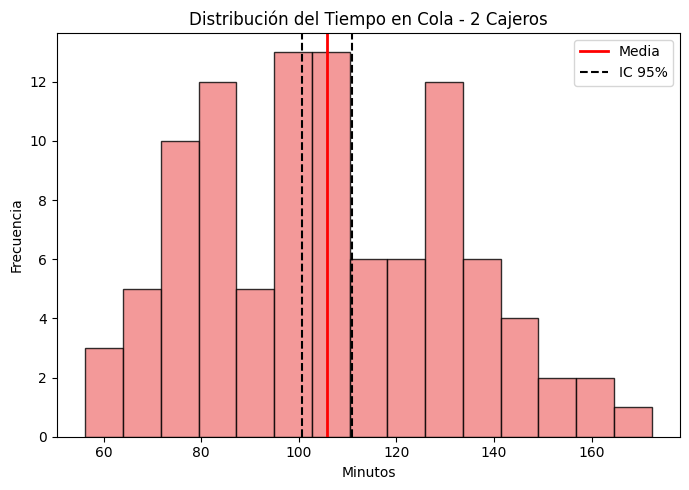

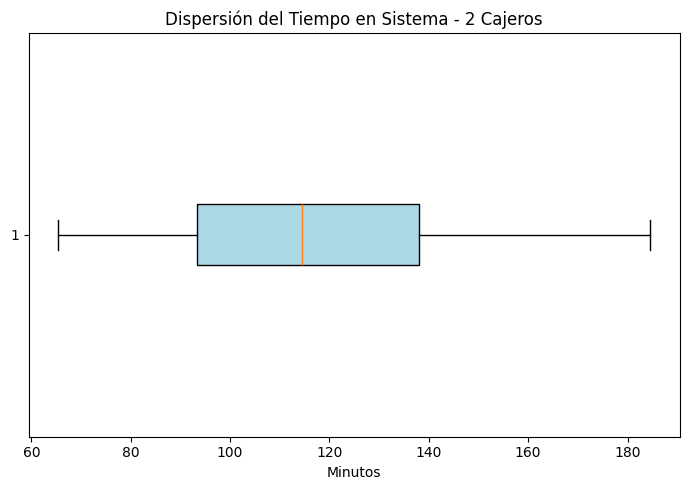

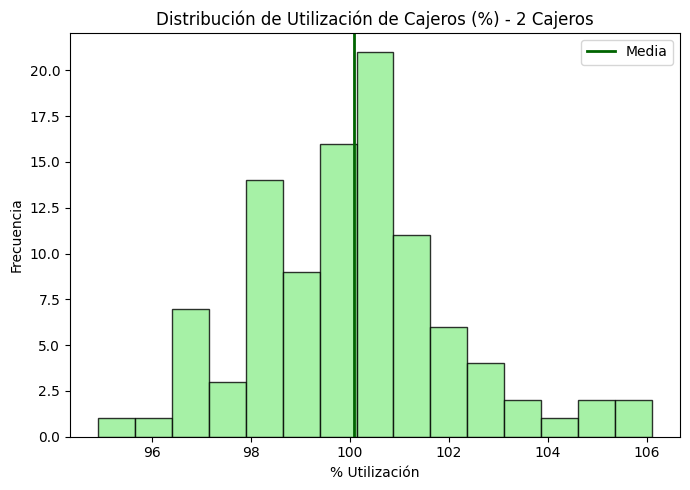


Ejecutando escenario con 4 cajeros (100 réplicas)...


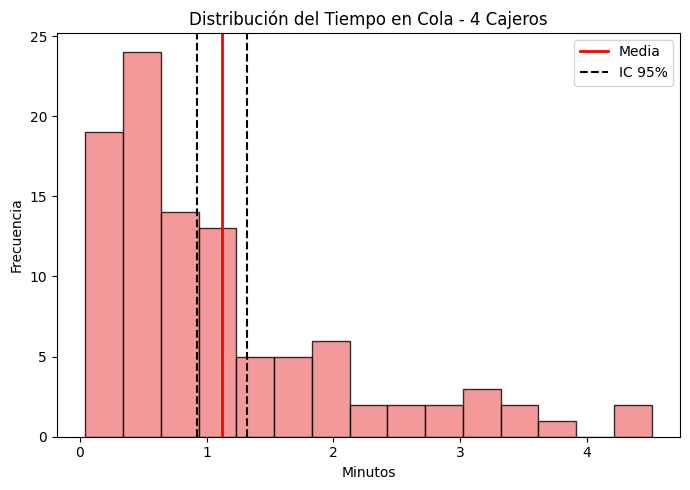

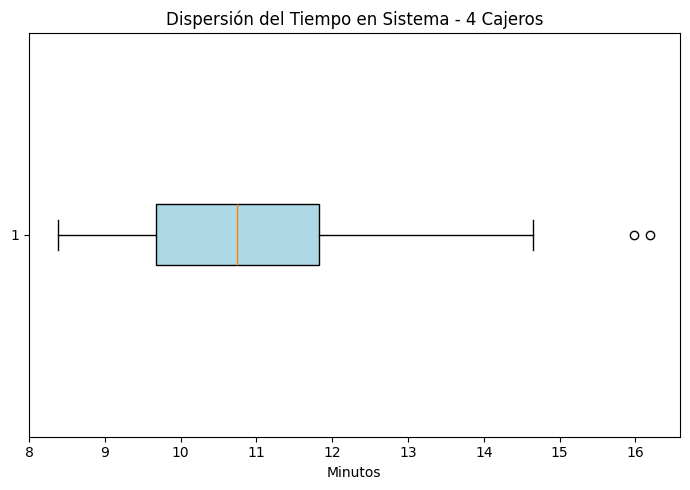

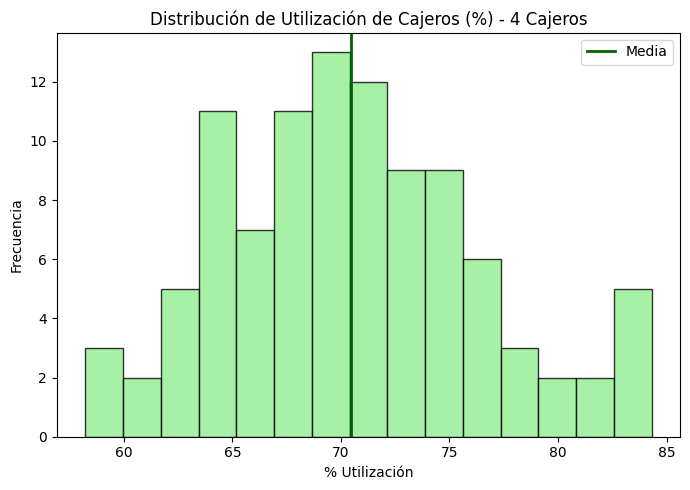


Ejecutando escenario con 6 cajeros (100 réplicas)...


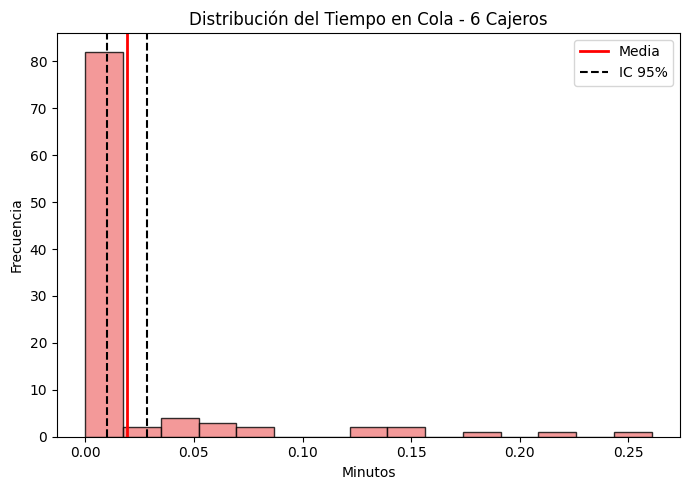

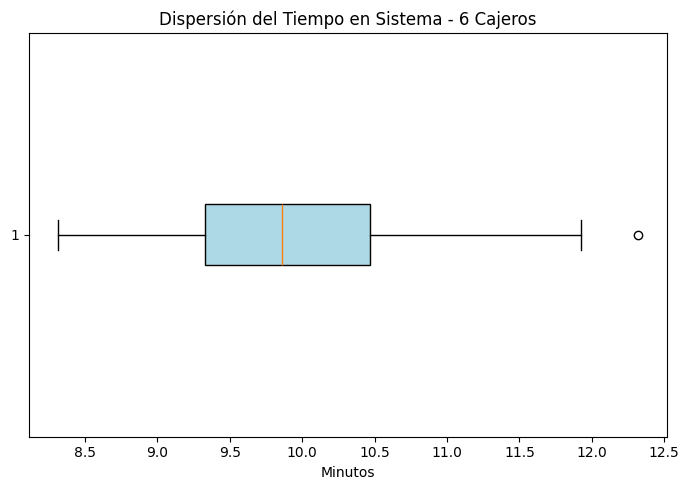

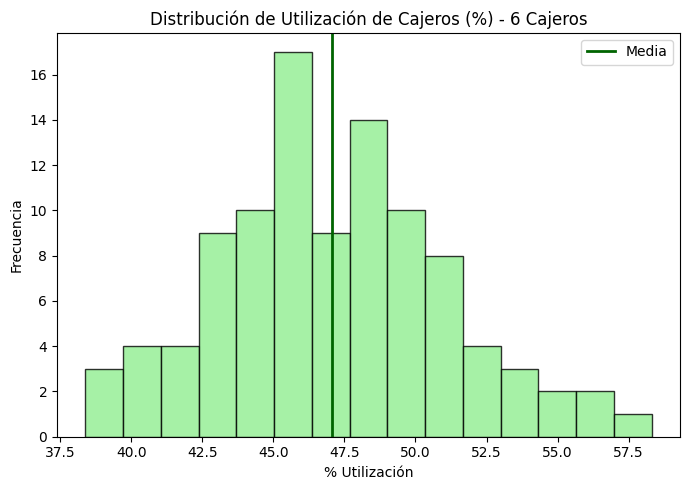

In [12]:
escenarios = [2, 4, 6]
tabla_resumen = []
rutas_graficas = {}

for n in escenarios:
    print(f"\nEjecutando escenario con {n} cajeros ({NUM_REPLICACIONES} réplicas)...")
    df = ejecutar_escenario(n)

    media_espera, li_espera, ls_espera = calcular_intervalo_confianza(df['Espera_Cola'])
    media_sistema, li_sistema, ls_sistema = calcular_intervalo_confianza(df['Tiempo_Sistema'])
    media_util, li_util, ls_util = calcular_intervalo_confianza(df['Utilizacion'] * 100)

    tabla_resumen.append({
        'Cajeros': n,
        'Tiempo_Prom_Espera (min)': round(media_espera, 2),
        'Tiempo_Prom_Sistema (min)': round(media_sistema, 2),
        'Utilizacion_Prom (%)': round(media_util, 2),
        'IC95_Espera_LI': round(li_espera, 2),
        'IC95_Espera_LS': round(ls_espera, 2),
    })

    rutas_graficas[n] = generar_graficas_escenario(df, n)
    df.to_csv(f"resultados_{n}cajeros.csv", index=False)

df_resumen = pd.DataFrame(tabla_resumen)
df_resumen.to_csv("tabla_comparativa_escenarios.csv", index=False)

## 7. Tabla comparativa de resultados

In [13]:
print("=" * 60)
print(" TABLA COMPARATIVA DE ESCENARIOS")
print("=" * 60)
df_resumen

 TABLA COMPARATIVA DE ESCENARIOS


,Cajeros,Tiempo_Prom_Espera (min),Tiempo_Prom_Sistema (min),Utilizacion_Prom (%),IC95_Espera_LI,IC95_Espera_LS
0,2,105.84,116.04,100.08,100.73,110.95
1,4,1.12,11.02,70.46,0.92,1.32
2,6,0.02,9.93,47.06,0.01,0.03


## 8. Conclusión

- **2 cajeros:** el sistema colapsa (utilización ≈100%, esperas superiores a 100 minutos) porque la capacidad de servicio es menor que la tasa de llegada.
- **4 cajeros:** escenario recomendado. Tiempo de espera muy bajo (~1 minuto) con una utilización eficiente (~70%).
- **6 cajeros:** sobredimensionado. Espera prácticamente nula, pero utilización baja (~47%), lo que implica personal ocioso.

**Recomendación:** operar con **4 cajeros**, ya que ofrece el mejor equilibrio entre nivel de servicio y costo operativo.